STalign Real-Data Example: Affine vs Full
========================================

This notebook is a Squidpy version of the upstream STalign MERFISH affine-only workflow, using the real
MERFISH CSVs shipped in `tmp/STalign_upstream`.

It compares three stages:
- manual affine prealignment, following the spirit of the upstream notebook
- affine-only refinement using the experimental Squidpy STalign implementation
- full STalign refinement with diffeomorphic updates enabled

The notebook intentionally lives under `tmp/` and is meant as a practical working example.

In [2]:
from __future__ import annotations

%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from anndata import AnnData

import squidpy as sq


def _find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "src" / "squidpy").exists():
            return path
    raise FileNotFoundError("Could not locate the squidpy repo root from the current working directory.")


REPO_ROOT = _find_repo_root(Path.cwd().resolve())
DATA_DIR = REPO_ROOT / "tmp" / "stalign_merfish_data"
if not DATA_DIR.exists():
    raise FileNotFoundError(f"Expected STalign tutorial data under: {DATA_DIR}")

FileNotFoundError: Expected STalign tutorial data under: /Users/selman/projects/squidpy/tmp/STalign_upstream/docs/merfish_data

Load the same real MERFISH files used by the upstream STalign examples.

The full CSVs are large enough to be slow for an interactive example, so this notebook subsamples them for a faster run.

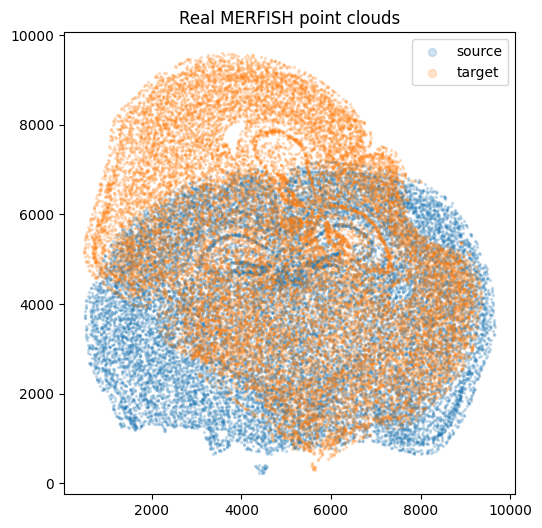

In [ ]:
src_path = DATA_DIR / "datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate3_cell_metadata_S2R3.csv.gz"
tgt_path = DATA_DIR / "datasets_mouse_brain_map_BrainReceptorShowcase_Slice2_Replicate2_cell_metadata_S2R2.csv.gz"

df_src = pd.read_csv(src_path)
df_tgt = pd.read_csv(tgt_path)

source_xy_full = df_src[["center_x", "center_y"]].to_numpy(dtype=float)
target_xy_full = df_tgt[["center_x", "center_y"]].to_numpy(dtype=float)

source_xy = source_xy_full[::4]
target_xy = target_xy_full[::4]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(source_xy[:, 0], source_xy[:, 1], s=2, alpha=0.2, label="source")
ax.scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax.set_title("Real MERFISH point clouds")
ax.legend(markerscale=4)
ax.set_aspect("equal")

Manual affine prealignment
-------------------------

This follows the upstream notebook pattern: choose a rough rotation angle, rotate the source, then translate it so its centroid lands near the target centroid.

In the upstream notebook this is a user-tuned step. Here we keep the parameter explicit so you can adjust it if needed.

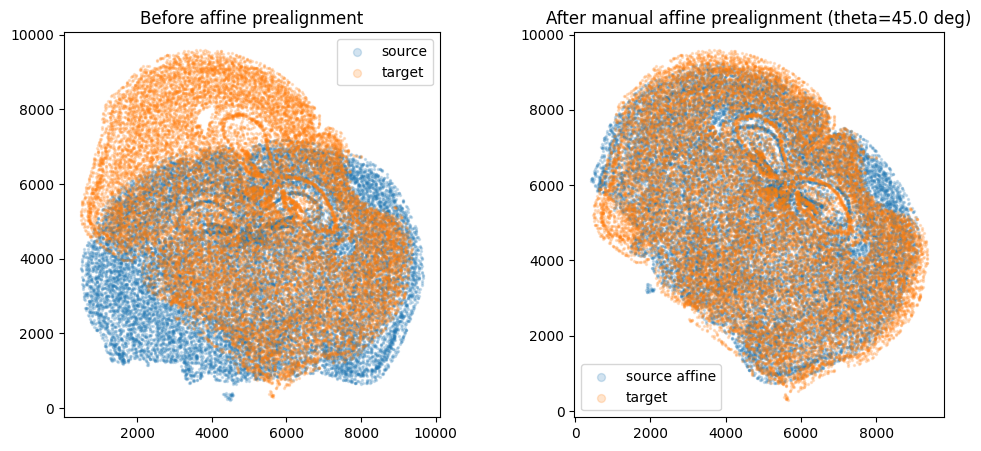

In [ ]:
theta_deg = 45.0
theta0 = np.deg2rad(-theta_deg)

linear = np.array(
    [
        [np.cos(theta0), -np.sin(theta0)],
        [np.sin(theta0), np.cos(theta0)],
    ]
)

source_rot = source_xy @ linear.T
translation = target_xy.mean(axis=0) - source_rot.mean(axis=0)
source_affine_xy = source_rot + translation

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(source_xy[:, 0], source_xy[:, 1], s=2, alpha=0.2, label="source")
ax[0].scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax[0].set_title("Before affine prealignment")
ax[0].legend(markerscale=4)
ax[0].set_aspect("equal")

ax[1].scatter(source_affine_xy[:, 0], source_affine_xy[:, 1], s=2, alpha=0.2, label="source affine")
ax[1].scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax[1].set_title(f"After manual affine prealignment (theta={theta_deg:.1f} deg)")
ax[1].legend(markerscale=4)
ax[1].set_aspect("equal")

In [ ]:
adata_src_affine = AnnData(np.zeros((source_affine_xy.shape[0], 1), dtype=float))
adata_src_affine.obsm["spatial"] = source_affine_xy

adata_tgt = AnnData(np.zeros((target_xy.shape[0], 1), dtype=float))
adata_tgt.obsm["spatial"] = target_xy

Affine-only refinement
----------------------

To get affine-only behavior with the current Squidpy implementation, we start from the manually affine-transformed source points and set `diffeo_start > niter`, which prevents the velocity field from being updated.

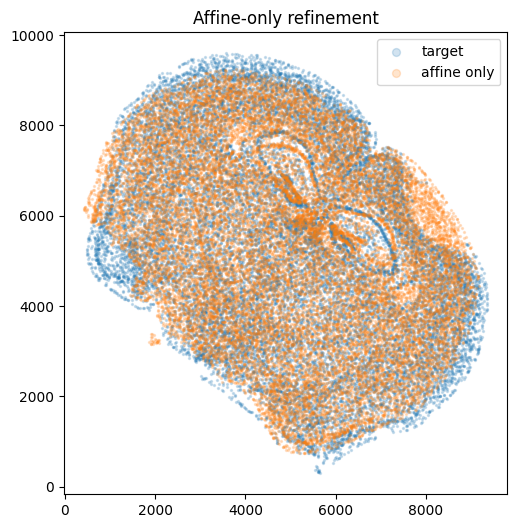

In [ ]:
affine_only_config = sq.experimental.tl.stalign_tools.STalignConfig(
    preprocess=sq.experimental.tl.stalign_tools.STalignPreprocessConfig(
        dx=30.0,
        blur=1.5,
    ),
    registration=sq.experimental.tl.stalign_tools.STalignRegistrationConfig(
        a=500.0,
        expand=1.0,
        nt=1,
        niter=10,
        diffeo_start=11,
        epV=50.0,
    ),
)
affine_only = sq.experimental.tl.stalign(
    adata_src_affine,
    adata_tgt,
    src_key="spatial",
    tgt_key="spatial",
    config=affine_only_config,
)

affine_only_xy = np.asarray(affine_only.aligned_points)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax.scatter(affine_only_xy[:, 0], affine_only_xy[:, 1], s=2, alpha=0.2, label="affine only")
ax.set_title("Affine-only refinement")
ax.legend(markerscale=4)
ax.set_aspect("equal")

Full STalign refinement
-----------------------

Now run the same problem with diffeomorphic refinement enabled.

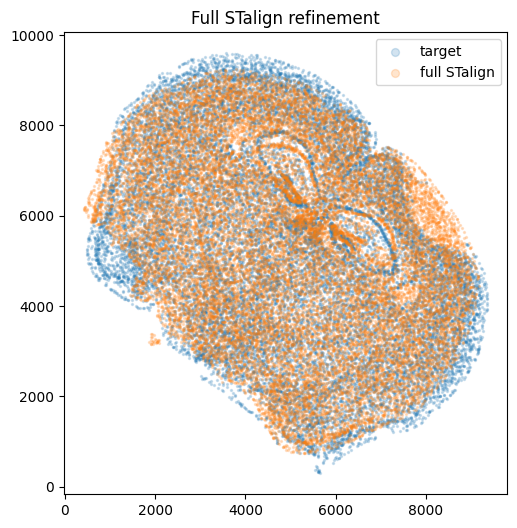

In [ ]:
full_config = sq.experimental.tl.stalign_tools.STalignConfig(
    preprocess=sq.experimental.tl.stalign_tools.STalignPreprocessConfig(
        dx=30.0,
        blur=1.5,
    ),
    registration=sq.experimental.tl.stalign_tools.STalignRegistrationConfig(
        a=500.0,
        expand=1.0,
        nt=1,
        niter=10,
        diffeo_start=0,
        epV=50.0,
    ),
)
full_result = sq.experimental.tl.stalign(
    adata_src_affine,
    adata_tgt,
    src_key="spatial",
    tgt_key="spatial",
    config=full_config,
)

full_xy = np.asarray(full_result.aligned_points)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax.scatter(full_xy[:, 0], full_xy[:, 1], s=2, alpha=0.2, label="full STalign")
ax.set_title("Full STalign refinement")
ax.legend(markerscale=4)
ax.set_aspect("equal")

Compare manual affine, affine-only refinement, and full STalign on the same axes.

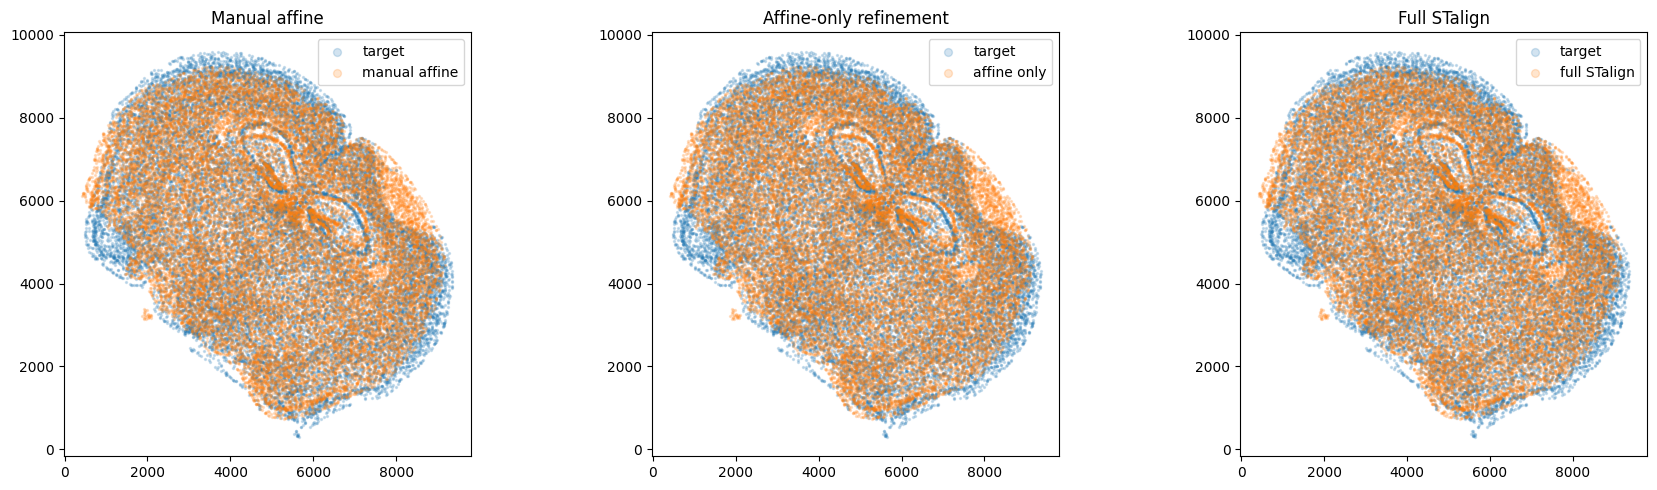

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax[0].scatter(source_affine_xy[:, 0], source_affine_xy[:, 1], s=2, alpha=0.2, label="manual affine")
ax[0].set_title("Manual affine")
ax[0].legend(markerscale=4)
ax[0].set_aspect("equal")

ax[1].scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax[1].scatter(affine_only_xy[:, 0], affine_only_xy[:, 1], s=2, alpha=0.2, label="affine only")
ax[1].set_title("Affine-only refinement")
ax[1].legend(markerscale=4)
ax[1].set_aspect("equal")

ax[2].scatter(target_xy[:, 0], target_xy[:, 1], s=2, alpha=0.2, label="target")
ax[2].scatter(full_xy[:, 0], full_xy[:, 1], s=2, alpha=0.2, label="full STalign")
ax[2].set_title("Full STalign")
ax[2].legend(markerscale=4)
ax[2].set_aspect("equal")

plt.tight_layout()

Reference
---------

This notebook is inspired by the upstream STalign affine-only MERFISH notebook:
`tmp/STalign_upstream/docs/notebooks/merfish-merfish-alignment-affine-only.ipynb`

The main difference is that this version runs through the experimental Squidpy API and compares affine-only
behavior against full STalign refinement in one place.